In [25]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import ConnectionPatch


def visualize_qps(csv_path: Path,
                  power_df_dvfs: pd.DataFrame, 
                  power_df_ours: pd.DataFrame, 
                  time_bucket_ms: int = 10000, 
                  save_name: str = None, 
                  start_time: int = 0,
                  end_time: int = 5 * 60, ):
    """
    Generate a plot showing QPS for the first 35 minutes from an LLM inference request trace.
    """
    # Read the CSV
    df = pd.read_csv(csv_path)

    # Convert arrived_at to microseconds relative to first request
    df = df[(df['arrived_at'] >= start_time) & (df['arrived_at'] <= end_time)]
    df['timestamp_us'] = (df['arrived_at'] - start_time) * 1e6

    # Compute time bucket for each row
    df['time_bucket'] = (df['timestamp_us'] // (time_bucket_ms * 1000)).astype(int)

    # Aggregate QPS
    agg = df.groupby('time_bucket').agg(
        qps=('timestamp_us', 'count'),
        tps=('num_decode_tokens', 'sum')
    ).reset_index()


    # Fill in missing time buckets with zeroes
    all_buckets = pd.DataFrame({
        'time_bucket': np.arange(df['time_bucket'].min(), df['time_bucket'].max() + 1)
    })
    agg = pd.merge(all_buckets, agg, on='time_bucket', how='left').fillna(0)

    agg['qps'] = agg['qps'] / (time_bucket_ms / 1000.0)
    agg['tps'] = agg['tps'] / (time_bucket_ms / 1000.0)
    # Filter data for the first 35 minutes
    max_time_bucket = end_time 
    agg = agg[agg['time_bucket'] <= max_time_bucket]



    # Create a figure with two subplots in a single column
    fig, axes = plt.subplots(6, 1, figsize=(6, 8), constrained_layout=True, sharex=True)

    sns.set_theme(context="paper", style="whitegrid")

    sns.lineplot(x=agg['time_bucket'] * (time_bucket_ms / 1000.0) / 60, y=agg['qps'], ax=axes[0])
    axes[0].set_ylabel('RPS', fontsize=15)
    axes[0].set_ylim(0, 200)
    axes[0].tick_params(axis='both', which='major', labelsize=14)
    
    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['freq_x'], ax=axes[1], color='blue', linestyle='--')
    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['freq_y'], ax=axes[1], color='blue', linestyle='-')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['freq_x'], ax=axes[1], color='orange', linestyle='--')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['freq_y'], ax=axes[1], color='orange', linestyle='-')
    axes[1].set_ylabel('Frequency\n(MHz)', fontsize=15)
    axes[1].tick_params(axis='both', which='major', labelsize=14)
    axes[1].set_ylim(0, 1900)

    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['power_x'], ax=axes[2], color='blue', linestyle='--')
    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['power_y'], ax=axes[2], color='blue', linestyle='-')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['power_x'], ax=axes[2], color='orange', linestyle='--')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['power_y'], ax=axes[2], color='orange', linestyle='-')
    axes[2].set_ylabel('Power\n(W)', fontsize=15)
    axes[2].tick_params(axis='both', which='major', labelsize=14)
    axes[2].set_ylim(0, 3000)
    axes[2].set_xlim(0, 5)

    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['power'], ax=axes[3], color='blue')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['power'], ax=axes[3], color='orange')
    axes[3].set_ylabel('Total\npower (W)', fontsize=15)
    axes[3].tick_params(axis='both', which='major', labelsize=14)
    axes[3].set_ylim(0, 6500)

    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['run_q'], ax=axes[4], color='blue')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['run_q'], ax=axes[4], color='orange')
    axes[4].set_ylabel('Batch\nsize', fontsize=15)
    axes[4].tick_params(axis='both', which='major', labelsize=14)
    axes[4].set_ylim(0, 2000)

    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['tpot_x'], ax=axes[5], color='blue', linestyle='--')
    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['tpot_y'], ax=axes[5], color='blue', linestyle='-')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['tpot_x'], ax=axes[5], color='orange', linestyle='--')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['tpot_y'], ax=axes[5], color='orange', linestyle='-')
    axes[5].set_ylabel('Batch\nlatency(s)', fontsize=15)
    axes[5].tick_params(axis='both', which='major', labelsize=14)
    axes[5].set_ylim(0, 0.110)

    axes[5].set_xlabel('Time (minutes)', fontsize=15)

    # Add a single legend at the top
    handles = [
        plt.Line2D([], [], color='blue', linestyle='-', linewidth=4, label='PlaceOnly'),
        plt.Line2D([], [], color='orange', linestyle='-', linewidth=4, label='BiScale')
    ]
    fig.legend(handles=handles, loc='upper center', fontsize=14, ncol=2, bbox_to_anchor=(0.6, 1.0))

    con = ConnectionPatch(
        xyA=(0.5, 1.0), coordsA=axes[0].get_xaxis_transform(),
        xyB=(0.5, 0.0), coordsB=axes[-1].get_xaxis_transform(),
        color='red', linestyle='--', linewidth=1.5
    )
    fig.add_artist(con)

    # Show the plots
    plt.show()

    # # Save the figure if save_name is provided
    if save_name:
        fig.savefig(save_name, format="pdf")


def get_combined_df(power_csv_paths: list[Path]) -> pd.DataFrame:
    combined_df = None
    for path in power_csv_paths:
        df = pd.read_csv(path / "power_log.csv")
        stats_df = pd.read_csv(path / "engine_0.csv")
        df = df[(df['Timestamp'] > stats_df['now'].min()) & (df['Timestamp'] < stats_df['now'].max())]
        df['power'] = df[[col for col in df.columns if col.startswith("GPU_") and col.endswith("_power_w")]].sum(axis=1)
        df["freq"] = df[[col for col in df.columns if col.startswith("GPU_") and col.endswith("_freq_mhz")]].mean(axis=1)
        if combined_df is None:
            combined_df = df[['Timestamp', 'power', 'freq']].copy()
        else:
            combined_df = pd.merge_asof(combined_df.sort_values('Timestamp'), 
                                        df[['Timestamp', 'power', 'freq']].sort_values('Timestamp'), 
                                        on='Timestamp', 
                                        direction='nearest')
            combined_df['power'] = combined_df['power_x'] + combined_df['power_y']
            # combined_df = combined_df.drop(columns=['power_x', 'power_y'])

    run_q_df = None
    for path in power_csv_paths:
        stats_df = pd.read_csv(path / "engine_0.csv")
        stats_df['inter_token_latencies_iter_evald'] = stats_df['inter_token_latencies_iter'].apply(eval)
        stats_df['tpot'] = stats_df['inter_token_latencies_iter_evald'].apply(lambda x: np.median(x) if len(x) > 0 else 0)
        if run_q_df is None:
            run_q_df = stats_df[['now', 'num_running_reqs', 'tpot']].copy()
        else:
            run_q_df = pd.merge_asof(run_q_df.sort_values('now'), 
                                        stats_df[['now', 'num_running_reqs', 'tpot']].sort_values('now'), 
                                        on='now', 
                                        direction='nearest')
            run_q_df['run_q'] = run_q_df['num_running_reqs_x'] + run_q_df['num_running_reqs_y']
            run_q_df = run_q_df.drop(columns=['num_running_reqs_x', 'num_running_reqs_y'])
    
    combined_df = pd.merge_asof(combined_df.sort_values('Timestamp'), 
                                run_q_df.sort_values('now'),
                                left_on='Timestamp',
                                right_on='now',
                                direction='nearest')
    combined_df = combined_df.drop(columns=['now'])
    combined_df["Timestamp"] = combined_df["Timestamp"] - combined_df["Timestamp"].min()

    return combined_df

# Weighted DVFS - 85%

5-10 mins


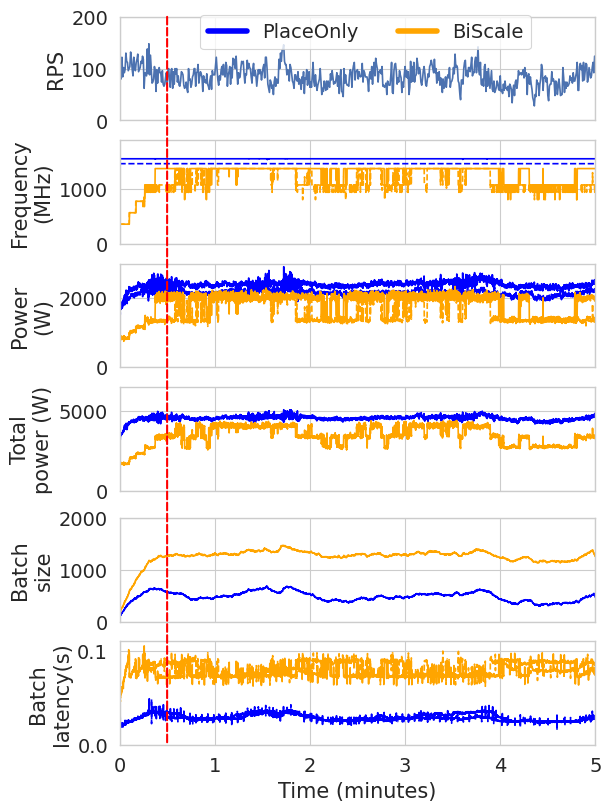

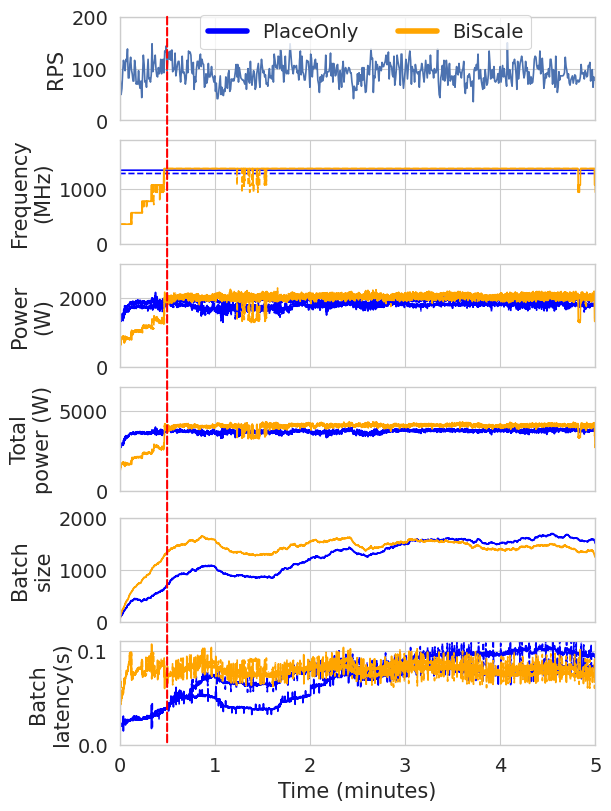

In [26]:
print("5-10 mins")
power_df_dvfs = get_combined_df([Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1_DVFS_W/decode_4_Jan06022833_gpu1'),
                                  Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1_DVFS_W/decode_4_Jan06022843')])
power_df_ours = get_combined_df([Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1/decode_4_Jan04214813_gpu1'),
                                  Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1/decode_4_Jan04214824')])
visualize_qps(csv_path=Path('azure_2024_code_sharegpt-ctx-len_qps88.27_req-cnt200000.csv'), 
              power_df_dvfs=power_df_dvfs,
              power_df_ours=power_df_ours,
              time_bucket_ms=500, 
              save_name="figs/power_freq_85p_5_10_decode.pdf",
              start_time=5 * 60,
              end_time=10 * 60)

# print("10-15 mins")
# power_df_dvfs = get_combined_df([Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_2_DVFS_W/decode_4_Jan06023739_gpu1'),
#                                   Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_2_DVFS_W/decode_4_Jan06023758')])
# power_df_ours = get_combined_df([Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_2/decode_4_Jan04215632_gpu1'),
#                                   Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_2/decode_4_Jan04215640')])
# visualize_qps(csv_path=Path('azure_2024_code_sharegpt-ctx-len_qps88.27_req-cnt200000.csv'), 
#               power_df_dvfs=power_df_dvfs,
#               power_df_ours=power_df_ours,
#               time_bucket_ms=500, 
#               save_name="figs/power_freq_85p_10_15_decode.pdf",
#               start_time=10 * 60,
#               end_time=15 * 60)

# print("20-25 mins")
power_df_dvfs = get_combined_df([Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_4_DVFS_W/decode_4_Jan06025642_gpu1'),
                                  Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_4_DVFS_W/decode_4_Jan06025647')])
power_df_ours = get_combined_df([Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_4/decode_4_Jan04221326_gpu1'),
                                  Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_4/decode_4_Jan04221330')])
visualize_qps(csv_path=Path('azure_2024_code_sharegpt-ctx-len_qps88.27_req-cnt200000.csv'), 
                power_df_dvfs=power_df_dvfs,
                power_df_ours=power_df_ours,
                time_bucket_ms=500, 
                save_name="figs/power_freq_85p_20_25_decode.pdf",
                start_time=20 * 60,
                end_time=25 * 60)


# Prefill

In [27]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import ConnectionPatch

def visualize_prefill(csv_path: Path,
                  power_df_dvfs: pd.DataFrame, 
                  power_df_ours: pd.DataFrame, 
                  time_bucket_ms: int = 10000, 
                  save_name: str = None, 
                  start_time: int = 0,
                  end_time: int = 5 * 60, ):
    """
    Generate a plot showing QPS for the first 35 minutes from an LLM inference request trace.
    """
    # Read the CSV
    df = pd.read_csv(csv_path)

    # Convert arrived_at to microseconds relative to first request
    df = df[(df['arrived_at'] >= start_time) & (df['arrived_at'] <= end_time)]
    df['timestamp_us'] = (df['arrived_at'] - start_time) * 1e6

    # Compute time bucket for each row
    df['time_bucket'] = (df['timestamp_us'] // (time_bucket_ms * 1000)).astype(int)

    # Aggregate QPS
    agg = df.groupby('time_bucket').agg(
        qps=('timestamp_us', 'count'),
        tps=('num_prefill_tokens', 'sum')
    ).reset_index()


    # Fill in missing time buckets with zeroes
    all_buckets = pd.DataFrame({
        'time_bucket': np.arange(df['time_bucket'].min(), df['time_bucket'].max() + 1)
    })
    agg = pd.merge(all_buckets, agg, on='time_bucket', how='left').fillna(0)

    agg['qps'] = agg['qps'] / (time_bucket_ms / 1000.0)
    agg['tps'] = agg['tps'] / (time_bucket_ms / 1000.0)
    # Filter data for the first 35 minutes
    max_time_bucket = end_time // (time_bucket_ms / 1000.0)
    agg = agg[agg['time_bucket'] <= max_time_bucket]


    fig, axes = plt.subplots(6, 1, figsize=(6, 8), constrained_layout=True, sharex=True)

    sns.set_theme(context="paper", style="whitegrid")

    ax = sns.lineplot(x=agg['time_bucket'] * (time_bucket_ms / 1000.0) / 60, y=agg['qps'], ax=axes[0])
    axes[0].set_ylabel('RPS', fontsize=15)
    axes[0].set_ylim(0, 200)
    axes[0].set_xlim(0, 5)
    axes[0].tick_params(axis='both', which='major', labelsize=14)

    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['freq_x1'], ax=axes[1], color='blue', linestyle='--')
    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['freq_y1'], ax=axes[1], color='blue', linestyle='-')
    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['freq_x3'], ax=axes[1], color='blue', linestyle=':')
    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['freq_y3'], ax=axes[1], color='blue', linestyle='-.')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['freq_x1'], ax=axes[1], color='orange', linestyle='--')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['freq_y1'], ax=axes[1], color='orange', linestyle='-')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['freq_x3'], ax=axes[1], color='orange', linestyle=':')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['freq_y3'], ax=axes[1], color='orange', linestyle='-.')
    axes[1].set_ylabel('Frequency\n(MHz)', fontsize=15)
    axes[1].tick_params(axis='both', which='major', labelsize=14)
    axes[1].set_ylim(0, 1900)
    axes[1].set_xlim(0, 5)


    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['power_x1'], ax=axes[2], color='blue', linestyle='--')
    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['power_y1'], ax=axes[2], color='blue', linestyle='-')
    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['power_x3'], ax=axes[2], color='blue', linestyle=':')
    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['power_y3'], ax=axes[2], color='blue', linestyle='-.')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['power_x1'], ax=axes[2], color='orange', linestyle='--')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['power_y1'], ax=axes[2], color='orange', linestyle='-')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['power_x3'], ax=axes[2], color='orange', linestyle=':')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['power_y3'], ax=axes[2], color='orange', linestyle='-.')
    axes[2].set_ylabel('Power\n(W)', fontsize=15)
    axes[2].tick_params(axis='both', which='major', labelsize=14)
    axes[2].set_ylim(0, 3000)
    axes[2].set_xlim(0, 5)

    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['power'], ax=axes[3], color='blue')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['power'], ax=axes[3], color='orange')
    axes[3].set_ylabel('Total\npower (W)', fontsize=15)
    axes[3].tick_params(axis='both', which='major', labelsize=14)
    axes[3].set_ylim(0, 6500)
    axes[3].set_xlim(0, 5)

    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['run_q'], ax=axes[4], color='blue')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['run_q'], ax=axes[4], color='orange')
    axes[4].set_ylabel('Batch\nsize', fontsize=15)
    axes[4].tick_params(axis='both', which='major', labelsize=14)
    axes[4].set_ylim(0, 50)
    axes[4].set_xlim(0, 5)

    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['ttft_x1'], ax=axes[5], color='blue', linestyle='--')
    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['ttft_y1'], ax=axes[5], color='blue', linestyle='-')
    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['ttft_x3'], ax=axes[5], color='blue', linestyle=':')
    sns.lineplot(x=power_df_ours['Timestamp'] / 60, y=power_df_ours['ttft_y3'], ax=axes[5], color='blue', linestyle='-.')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['ttft_x1'], ax=axes[5], color='orange', linestyle='--')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['ttft_y1'], ax=axes[5], color='orange', linestyle='-')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['ttft_x3'], ax=axes[5], color='orange', linestyle=':')
    sns.lineplot(x=power_df_dvfs['Timestamp'] / 60, y=power_df_dvfs['ttft_y3'], ax=axes[5], color='orange', linestyle='-.')
    axes[5].set_ylabel('Max\nTTFT (s)', fontsize=15)
    axes[5].tick_params(axis='both', which='major', labelsize=14)
    axes[5].set_ylim(0, 0.750)
    axes[5].set_xlim(0, 5)

    axes[5].set_xlabel('Time (minutes)', fontsize=15)

    # Add a single legend at the top
    handles = [
        plt.Line2D([], [], color='blue', linestyle='-', linewidth=4, label='PlaceOnly'),
        plt.Line2D([], [], color='orange', linestyle='-', linewidth=4, label='BiScale')
    ]
    fig.legend(handles=handles, loc='upper center', fontsize=14, ncol=2, bbox_to_anchor=(0.6, 1.0))

    con = ConnectionPatch(
        xyA=(0.5, 1.0), coordsA=axes[0].get_xaxis_transform(),
        xyB=(0.5, 0.0), coordsB=axes[-1].get_xaxis_transform(),
        color='red', linestyle='--', linewidth=1.5
    )
    fig.add_artist(con)

    # Show the plots
    plt.show()

    # # Save the figure if save_name is provided
    if save_name:
        fig.savefig(save_name, format="pdf")

def get_combined_df_prefill(power_csv_paths: list[Path]) -> pd.DataFrame:
    combined_df = None
    for i, path in enumerate(power_csv_paths):
        df = pd.read_csv(path / "power_log.csv")
        stats_df = pd.read_csv(path / "engine_0.csv")
        df = df[(df['Timestamp'] > stats_df['now'].min()) & (df['Timestamp'] < stats_df['now'].max())]
        df['power'] = df[[col for col in df.columns if col.startswith("GPU_") and col.endswith("_power_w")]].sum(axis=1)
        df['power'] = (
            df['power']
            .rolling(window=100, center=True)
            .mean()
        )
        df["freq"] = df[[col for col in df.columns if col.startswith("GPU_") and col.endswith("_freq_mhz")]].mean(axis=1)
        df['freq'] = (
            df['freq']
            .rolling(window=100, center=True)
            .mean()
        )
        if combined_df is None:
            combined_df = df[['Timestamp', 'power', 'freq']].copy()
        else:
            combined_df = pd.merge_asof(combined_df.sort_values('Timestamp'), 
                                        df[['Timestamp', 'power', 'freq']].sort_values('Timestamp'), 
                                        on='Timestamp', 
                                        direction='nearest', suffixes=(f'_x{i}', f'_y{i}'))
    combined_df['power'] = combined_df['power_x1'] + combined_df['power_y1'] + combined_df['power_x3'] + combined_df['power_y3']
    

    run_q_df = None
    for i, path in enumerate(power_csv_paths):
        stats_df = pd.read_csv(path / "engine_0.csv")
        stats_df['time_to_first_tokens_iter_evald'] = stats_df['time_to_first_tokens_iter'].apply(eval)
        stats_df['ttft'] = stats_df['time_to_first_tokens_iter_evald'].apply(lambda x: np.max(x) if len(x) > 0 else 0)
        stats_df['num_prompt_tokens_reqs_evald'] = stats_df['num_prompt_tokens_reqs'].apply(eval)
        stats_df['num_running_reqs'] = stats_df['num_prompt_tokens_reqs_evald'].apply(lambda x: len(x))
        if run_q_df is None:
            run_q_df = stats_df[['now', 'num_running_reqs', 'ttft']].copy()
        else:
            run_q_df = pd.merge_asof(run_q_df.sort_values('now'), 
                                        stats_df[['now', 'num_running_reqs', 'ttft']].sort_values('now'), 
                                        on='now', 
                                        direction='nearest', suffixes=(f'_x{i}', f'_y{i}'))
    run_q_df['run_q'] = run_q_df['num_running_reqs_x1'] + run_q_df['num_running_reqs_y1'] + run_q_df['num_running_reqs_x3'] + run_q_df['num_running_reqs_y3']
    run_q_df = run_q_df.drop(columns=['num_running_reqs_x1', 'num_running_reqs_y1', 'num_running_reqs_x3', 'num_running_reqs_y3'])
    combined_df = pd.merge_asof(combined_df.sort_values('Timestamp'), 
                                run_q_df.sort_values('now'),
                                left_on='Timestamp',
                                right_on='now',
                                direction='nearest')
    combined_df = combined_df.drop(columns=['now'])
    combined_df["Timestamp"] = combined_df["Timestamp"] - combined_df["Timestamp"].min()

    return combined_df

10-15 mins


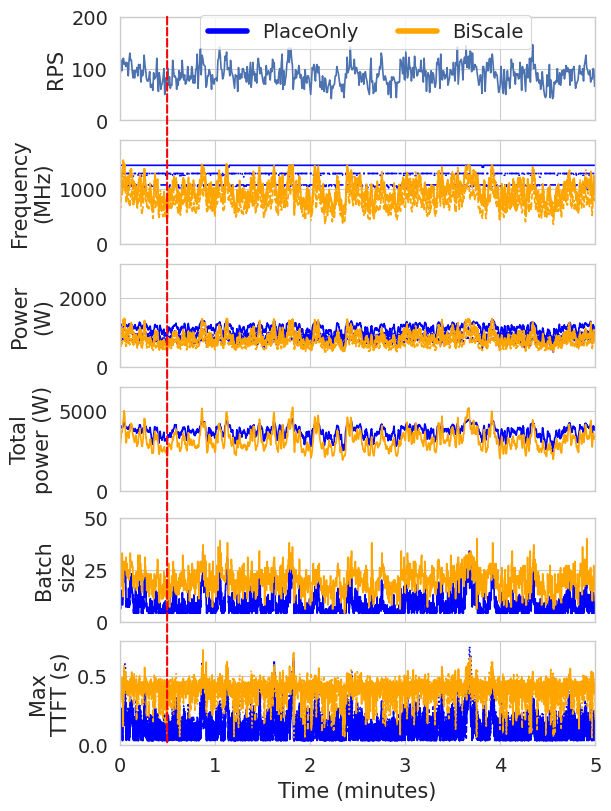

In [28]:
# print("5-10 mins")
# power_df_dvfs = get_combined_df_prefill([Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1_DVFS_W/prefill_0_Jan06022833_gpu1'),
#                                         Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1_DVFS_W/prefill_0_Jan06022843'),
#                                         Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1_DVFS_W/prefill_2_Jan06022833_gpu1'),
#                                         Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1_DVFS_W/prefill_2_Jan06022843')])
# power_df_ours = get_combined_df_prefill([Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1/prefill_0_Jan04214813_gpu1'),
#                                         Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1/prefill_0_Jan04214823'),
#                                         Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1/prefill_2_Jan04214813_gpu1'),
#                                         Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_1/prefill_2_Jan04214824')])
# visualize_prefill(csv_path=Path('azure_2024_code_sharegpt-ctx-len_qps88.27_req-cnt200000.csv'), 
#                     power_df_dvfs=power_df_dvfs,
#                     power_df_ours=power_df_ours,
#                     time_bucket_ms=500, 
#                     save_name="figs/power_freq_85p_5_10_prefill.pdf",
#                     start_time=5 * 60,
#                     end_time=10 * 60)

print("10-15 mins")
power_df_dvfs = get_combined_df_prefill([Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_2_DVFS_W/prefill_0_Jan06023738_gpu1'),
                                        Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_2_DVFS_W/prefill_0_Jan06023757'),
                                        Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_2_DVFS_W/prefill_2_Jan06023738_gpu1'),
                                        Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_2_DVFS_W/prefill_2_Jan06023758')])
power_df_ours = get_combined_df_prefill([Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_2/prefill_0_Jan04215632_gpu1'),
                                        Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_2/prefill_0_Jan04215640'),
                                        Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_2/prefill_2_Jan04215632_gpu1'),
                                        Path('/export2/obasit/ClusterLevelServing/vllm_logs/arxiv_evls/85_percent_char_balance/OURS_R5_JAN3_REAL_P85_2/prefill_2_Jan04215640')])
visualize_prefill(csv_path=Path('azure_2024_code_sharegpt-ctx-len_qps88.27_req-cnt200000.csv'), 
                    power_df_dvfs=power_df_dvfs,
                    power_df_ours=power_df_ours,
                    time_bucket_ms=500, 
                    save_name="figs/power_freq_85p_10_15_prefill.pdf",
                    start_time=10 * 60,
                    end_time=15 * 60)